In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import pickle

In [2]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

In [3]:
TAX_COLORS = {
    'S'    : '#ff4444',
    'C'    : '#4444ff',
    'X'    : '#ffaa00',
    'Other': '#44ff44',
}

In [4]:
core_path    = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)

unified_df = pd.read_pickle(os.path.join(results_path, 'unified_df.pkl'))

print(f"Dataset size : {len(unified_df):,}")
print(f"\nClass distribution:")
print(unified_df['Main Group'].value_counts())
print(f"\nFamily members : {unified_df['is_family_member'].sum():,}")
print(f"Background     : {(~unified_df['is_family_member']).sum():,}")

Dataset size : 1,181

Class distribution:
Main Group
S        488
C        357
X        196
Other    140
Name: count, dtype: int64

Family members : 275
Background     : 906


In [5]:
# ==========================================================
# ORBITAL FEATURES
# ==========================================================

ORBITAL_FEATURES = [
    'a_p',
    'e_p',
    'sin_i_p',
    'g',
    's'
]

# ==========================================================
# SPECTRAL FEATURES
# ==========================================================

SPECTRAL_FEATURES = [
    'slope_overall',
    'slope_vis',
    'slope_nir',
    'depth_07um',
    'depth_09um',
    'curvature',
    'ref_044',
    'ref_070',
    'ref_085',
    'ref_092',
    'ratio_nir_vis'
]

# ==========================================================
# COMBINED
# ==========================================================

ORBITAL_SPECTRAL_FEATURES = (
    ORBITAL_FEATURES +
    SPECTRAL_FEATURES
)

feature_sets = {
    'Orbital'          : ORBITAL_FEATURES,
    'Spectral'         : SPECTRAL_FEATURES,
    'Orbital+Spectral' : ORBITAL_SPECTRAL_FEATURES,
}

# Encode target
le = LabelEncoder()
y  = le.fit_transform(unified_df['Main Group'].values)
print(f"Classes: {le.classes_}")
print(f"Encoded: {np.unique(y)}")

# Class weights
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(le.classes_)),
    y=y
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"\nClass weights: {dict(zip(le.classes_, class_weights_arr.round(3)))}")

Classes: ['C' 'Other' 'S' 'X']
Encoded: [0 1 2 3]

Class weights: {'C': np.float64(0.827), 'Other': np.float64(2.109), 'S': np.float64(0.605), 'X': np.float64(1.506)}


In [6]:
CV       = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
SCORING = [
    'accuracy',
    'balanced_accuracy',
    'f1_macro',
    'f1_weighted'
]

# Results storage
all_cv_results = {}

print("Using 10-fold stratified cross-validation")
print(f"Scoring: {SCORING}")

Using 10-fold stratified cross-validation
Scoring: ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted']


In [7]:
print("\n" + "="*55)
print("Model 1: Random Forest")
print("="*55)

for feat_name, features in feature_sets.items():
    X      = unified_df[features].astype(float).values
    scaler = RobustScaler()
    X_s    = scaler.fit_transform(X)

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

    cv_res = cross_validate(rf, X_s, y, cv=CV,
                            scoring=SCORING,
                            return_train_score=True)

    acc  = cv_res['test_accuracy'].mean()
    f1m  = cv_res['test_f1_macro'].mean()
    f1w  = cv_res['test_f1_weighted'].mean()

    print(f"\n  {feat_name}")
    print(f"    Accuracy   : {acc:.4f} ± {cv_res['test_accuracy'].std():.4f}")
    print(f"    F1 Macro   : {f1m:.4f} ± {cv_res['test_f1_macro'].std():.4f}")
    print(f"    F1 Weighted: {f1w:.4f} ± {cv_res['test_f1_weighted'].std():.4f}")

    all_cv_results[f'RF_{feat_name}'] = {
        'model'   : 'RF',
        'features': feat_name,
        'acc'     : acc,
        'f1_macro': f1m,
        'f1_weighted': f1w,
        'acc_std' : cv_res['test_accuracy'].std(),
        'f1m_std' : cv_res['test_f1_macro'].std(),
    }


Model 1: Random Forest

  Orbital
    Accuracy   : 0.5546 ± 0.0264
    F1 Macro   : 0.4816 ± 0.0296
    F1 Weighted: 0.5512 ± 0.0232

  Spectral
    Accuracy   : 0.9433 ± 0.0194
    F1 Macro   : 0.9211 ± 0.0266
    F1 Weighted: 0.9431 ± 0.0198

  Orbital+Spectral
    Accuracy   : 0.9466 ± 0.0201
    F1 Macro   : 0.9258 ± 0.0283
    F1 Weighted: 0.9463 ± 0.0206


In [8]:
def evaluate_xgb(X, y):

    acc_scores  = []
    bacc_scores = []
    f1m_scores  = []
    f1w_scores  = []

    for train_idx, test_idx in CV.split(X, y):

        X_train = X[train_idx]
        X_test  = X[test_idx]

        y_train = y[train_idx]
        y_test  = y[test_idx]

        w_train = np.array([
            class_weights_arr[c]
            for c in y_train
        ])

        model = xgb.XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='mlogloss',
            random_state=42,
            n_jobs=-1
        )

        model.fit(
            X_train,
            y_train,
            sample_weight=w_train
        )

        pred = model.predict(X_test)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        f1m_scores.append(
            f1_score(
                y_test,
                pred,
                average='macro'
            )
        )

        f1w_scores.append(
            f1_score(
                y_test,
                pred,
                average='weighted'
            )
        )

    return {
        'acc'         : np.mean(acc_scores),
        'acc_std'     : np.std(acc_scores),
        'f1_macro'    : np.mean(f1m_scores),
        'f1m_std'     : np.std(f1m_scores),
        'f1_weighted' : np.mean(f1w_scores),
    }

In [9]:
print("\n" + "="*55)
print("Model 2: XGBoost")
print("="*55)

for feat_name, features in feature_sets.items():

    X = unified_df[
        features
    ].astype(float).values

    scaler = RobustScaler()
    X_s = scaler.fit_transform(X)

    res = evaluate_xgb(X_s, y)

    print(f"\n  {feat_name}")
    print(
        f"    Accuracy   : "
        f"{res['acc']:.4f} ± {res['acc_std']:.4f}"
    )
    print(
        f"    F1 Macro   : "
        f"{res['f1_macro']:.4f} ± {res['f1m_std']:.4f}"
    )
    print(
        f"    F1 Weighted: "
        f"{res['f1_weighted']:.4f}"
    )

    all_cv_results[f'XGB_{feat_name}'] = {
        'model'      : 'XGBoost',
        'features'   : feat_name,
        **res
    }


Model 2: XGBoost

  Orbital
    Accuracy   : 0.5537 ± 0.0258
    F1 Macro   : 0.4805 ± 0.0316
    F1 Weighted: 0.5510

  Spectral
    Accuracy   : 0.9500 ± 0.0116
    F1 Macro   : 0.9297 ± 0.0175
    F1 Weighted: 0.9496

  Orbital+Spectral
    Accuracy   : 0.9534 ± 0.0153
    F1 Macro   : 0.9374 ± 0.0206
    F1 Weighted: 0.9534


In [10]:
from sklearn.neural_network import MLPClassifier

print("\n" + "="*55)
print("Model 3: MLP")
print("="*55)

for feat_name, features in feature_sets.items():
    X      = unified_df[features].astype(float).values
    scaler = RobustScaler()
    X_s    = scaler.fit_transform(X)

    mlp = MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    )

    cv_res = cross_validate(mlp, X_s, y, cv=CV,
                            scoring=SCORING,
                            return_train_score=True)

    acc  = cv_res['test_accuracy'].mean()
    f1m  = cv_res['test_f1_macro'].mean()
    f1w  = cv_res['test_f1_weighted'].mean()

    print(f"\n  {feat_name}")
    print(f"    Accuracy   : {acc:.4f} ± {cv_res['test_accuracy'].std():.4f}")
    print(f"    F1 Macro   : {f1m:.4f} ± {cv_res['test_f1_macro'].std():.4f}")
    print(f"    F1 Weighted: {f1w:.4f} ± {cv_res['test_f1_weighted'].std():.4f}")

    all_cv_results[f'MLP_{feat_name}'] = {
        'model'      : 'MLP',
        'features'   : feat_name,
        'acc'        : acc,
        'f1_macro'   : f1m,
        'f1_weighted': f1w,
        'acc_std'    : cv_res['test_accuracy'].std(),
        'f1m_std'    : cv_res['test_f1_macro'].std(),
    }


Model 3: MLP

  Orbital
    Accuracy   : 0.5089 ± 0.0378
    F1 Macro   : 0.3146 ± 0.0545
    F1 Weighted: 0.4338 ± 0.0446

  Spectral
    Accuracy   : 0.9433 ± 0.0254
    F1 Macro   : 0.9181 ± 0.0410
    F1 Weighted: 0.9415 ± 0.0276

  Orbital+Spectral
    Accuracy   : 0.9432 ± 0.0166
    F1 Macro   : 0.9232 ± 0.0232
    F1 Weighted: 0.9429 ± 0.0163


In [11]:
results_df = pd.DataFrame(all_cv_results).T.reset_index()
results_df.columns = ['config'] + list(results_df.columns[1:])

print(f"\n{'='*75}")
print(f"{'Taxonomy Prediction — Full Summary':^75}")
print(f"{'='*75}")
print(f"{'Config':<35} {'Acc':>8} {'F1 Macro':>10} {'F1 Weighted':>12}")
print(f"{'-'*75}")

for _, row in results_df.sort_values('f1_macro', ascending=False).iterrows():
    print(f"{row['config']:<35} {float(row['acc']):>8.4f} "
          f"{float(row['f1_macro']):>10.4f} "
          f"{float(row['f1_weighted']):>12.4f}")


                    Taxonomy Prediction — Full Summary                     
Config                                   Acc   F1 Macro  F1 Weighted
---------------------------------------------------------------------------
XGB_Orbital+Spectral                  0.9534     0.9374       0.9534
XGB_Spectral                          0.9500     0.9297       0.9496
RF_Orbital+Spectral                   0.9466     0.9258       0.9463
MLP_Orbital+Spectral                  0.9432     0.9232       0.9429
RF_Spectral                           0.9433     0.9211       0.9431
MLP_Spectral                          0.9433     0.9181       0.9415
RF_Orbital                            0.5546     0.4816       0.5512
XGB_Orbital                           0.5537     0.4805       0.5510
MLP_Orbital                           0.5089     0.3146       0.4338


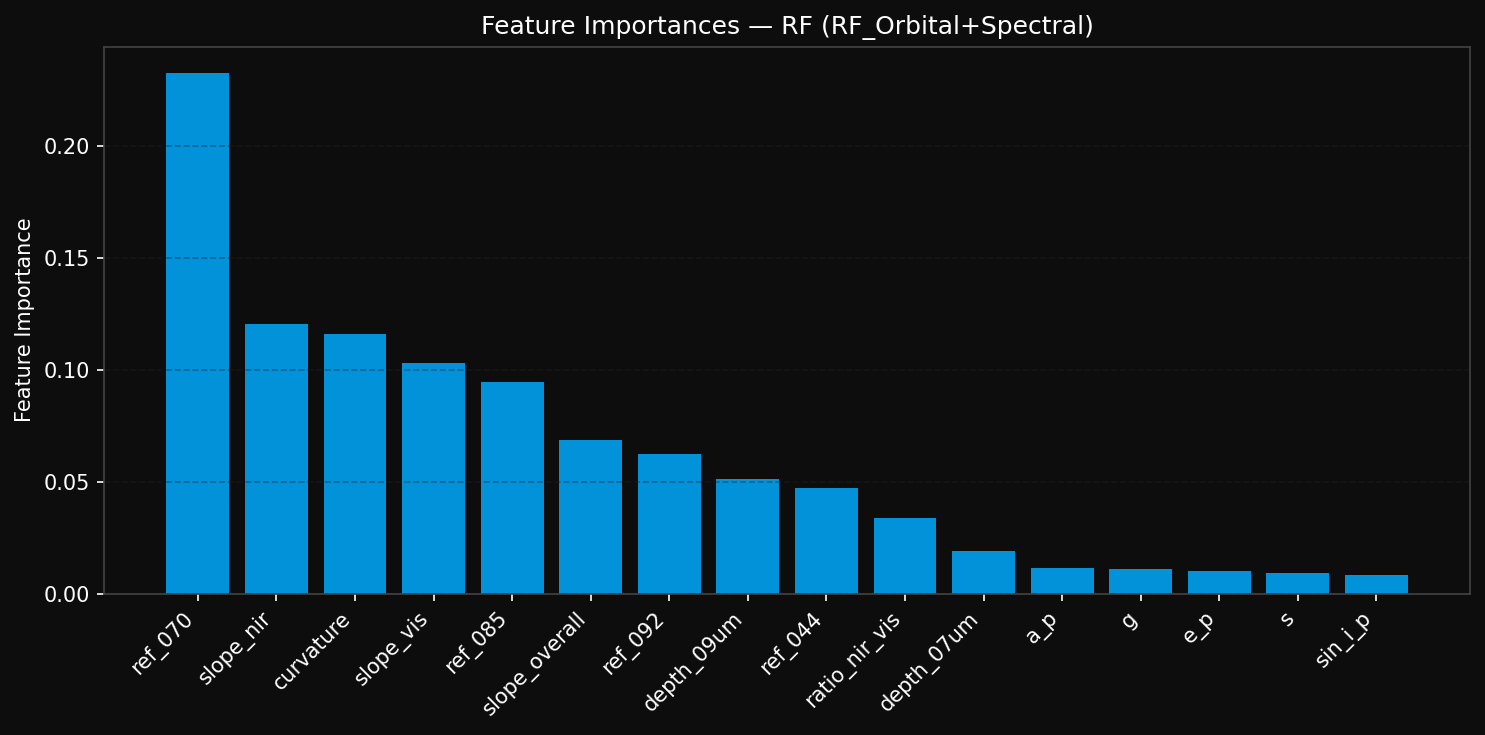


Feature importances:
  ref_070              : 0.2330
  slope_nir            : 0.1204
  curvature            : 0.1162
  slope_vis            : 0.1033
  ref_085              : 0.0944
  slope_overall        : 0.0687
  ref_092              : 0.0625
  depth_09um           : 0.0513
  ref_044              : 0.0474
  ratio_nir_vis        : 0.0336
  depth_07um           : 0.0192
  a_p                  : 0.0112
  g                    : 0.0111
  e_p                  : 0.0102
  s                    : 0.0091
  sin_i_p              : 0.0085


In [12]:
# Fit RF on full data with best feature set to get importances
best_feat_name = max(
    {k: v for k, v in all_cv_results.items() if v['model'] == 'RF'},
    key=lambda k: all_cv_results[k]['f1_macro']
)
best_features = feature_sets[all_cv_results[best_feat_name]['features']]

X_best  = unified_df[best_features].astype(float).values
scaler  = RobustScaler()
X_best_s = scaler.fit_transform(X_best)

rf_best = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    n_jobs=-1, random_state=42
)
rf_best.fit(X_best_s, y)

importances = rf_best.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(best_features)),
       importances[sorted_idx],
       color='#00aaff', edgecolor='none', alpha=0.85)
ax.set_xticks(range(len(best_features)))
ax.set_xticklabels([best_features[i] for i in sorted_idx],
                   rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title(f'Feature Importances — RF ({best_feat_name})')
ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05_feature_importances.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

print("\nFeature importances:")
for i in sorted_idx:
    print(f"  {best_features[i]:<20} : {importances[i]:.4f}")

In [13]:
print("\n" + "="*60)
print("Family Members vs Background — RF Orbital Only")
print("="*60)

X_orb = unified_df[ORBITAL_FEATURES].astype(float).values
scaler = RobustScaler()
X_orb_s = scaler.fit_transform(X_orb)

fam_mask = unified_df['is_family_member'].values
bg_mask  = ~fam_mask

rf_eval = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    n_jobs=-1, random_state=42
)

# Full CV
cv_full = cross_validate(rf_eval, X_orb_s, y,
                         cv=CV, scoring=SCORING)

# Family members only CV
if fam_mask.sum() >= 50:
    cv_fam = cross_validate(
        RandomForestClassifier(n_estimators=300,
                               class_weight='balanced',
                               n_jobs=-1, random_state=42),
        X_orb_s[fam_mask], y[fam_mask],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring=SCORING
    )
    fam_f1  = cv_fam['test_f1_macro'].mean()
    fam_acc = cv_fam['test_accuracy'].mean()
else:
    fam_f1 = fam_acc = np.nan

# Background only CV
cv_bg = cross_validate(
    RandomForestClassifier(n_estimators=300,
                           class_weight='balanced',
                           n_jobs=-1, random_state=42),
    X_orb_s[bg_mask], y[bg_mask],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=SCORING
)
bg_f1  = cv_bg['test_f1_macro'].mean()
bg_acc = cv_bg['test_accuracy'].mean()

print(f"\n{'Population':<20} {'N':>6} {'Accuracy':>10} {'F1 Macro':>10}")
print("-" * 50)
print(f"{'Full dataset':<20} {len(unified_df):>6} "
      f"{cv_full['test_accuracy'].mean():>10.4f} "
      f"{cv_full['test_f1_macro'].mean():>10.4f}")
print(f"{'Family members':<20} {fam_mask.sum():>6} "
      f"{fam_acc:>10.4f} {fam_f1:>10.4f}")
print(f"{'Background':<20} {bg_mask.sum():>6} "
      f"{bg_acc:>10.4f} {bg_f1:>10.4f}")

print("\nKey question: Is family membership accuracy > background accuracy?")
if not np.isnan(fam_f1):
    delta = fam_f1 - bg_f1
    print(f"  Delta F1 Macro (family - background) = {delta:+.4f}")
    if delta > 0.05:
        print("  → YES — family membership improves taxonomy prediction")
        print("    Orbital dynamics encodes compositional information")
    elif delta < -0.05:
        print("  → REVERSED — background easier to classify than family members")
    else:
        print("  → NO SIGNIFICANT DIFFERENCE")


Family Members vs Background — RF Orbital Only

Population                N   Accuracy   F1 Macro
--------------------------------------------------
Full dataset           1181     0.5698     0.4813
Family members          275     0.8218     0.7346
Background              906     0.4834     0.3858

Key question: Is family membership accuracy > background accuracy?
  Delta F1 Macro (family - background) = +0.3488
  → YES — family membership improves taxonomy prediction
    Orbital dynamics encodes compositional information



BEST MODEL HOLDOUT PERFORMANCE
Accuracy    : 0.9451
F1 Macro    : 0.9248
F1 Weighted : 0.9451


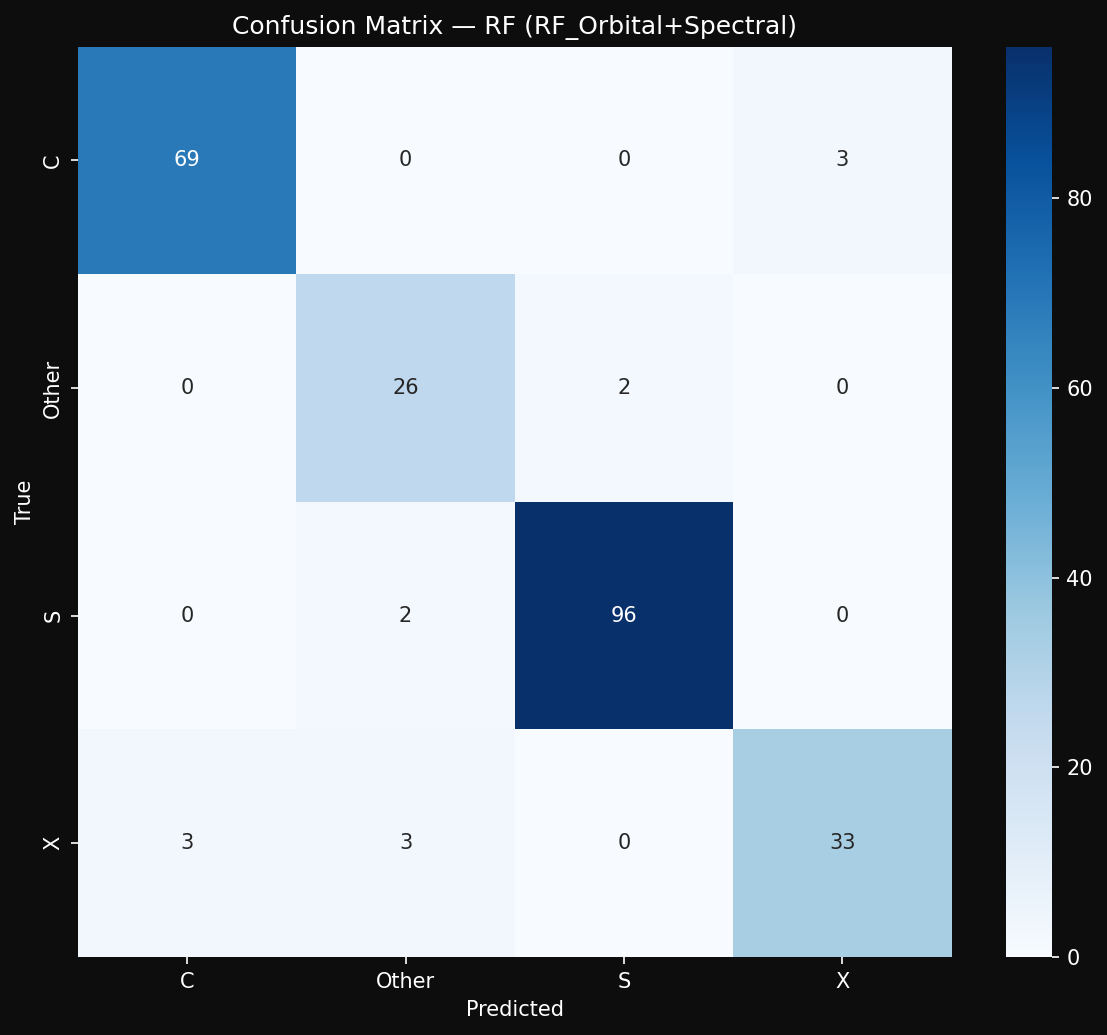

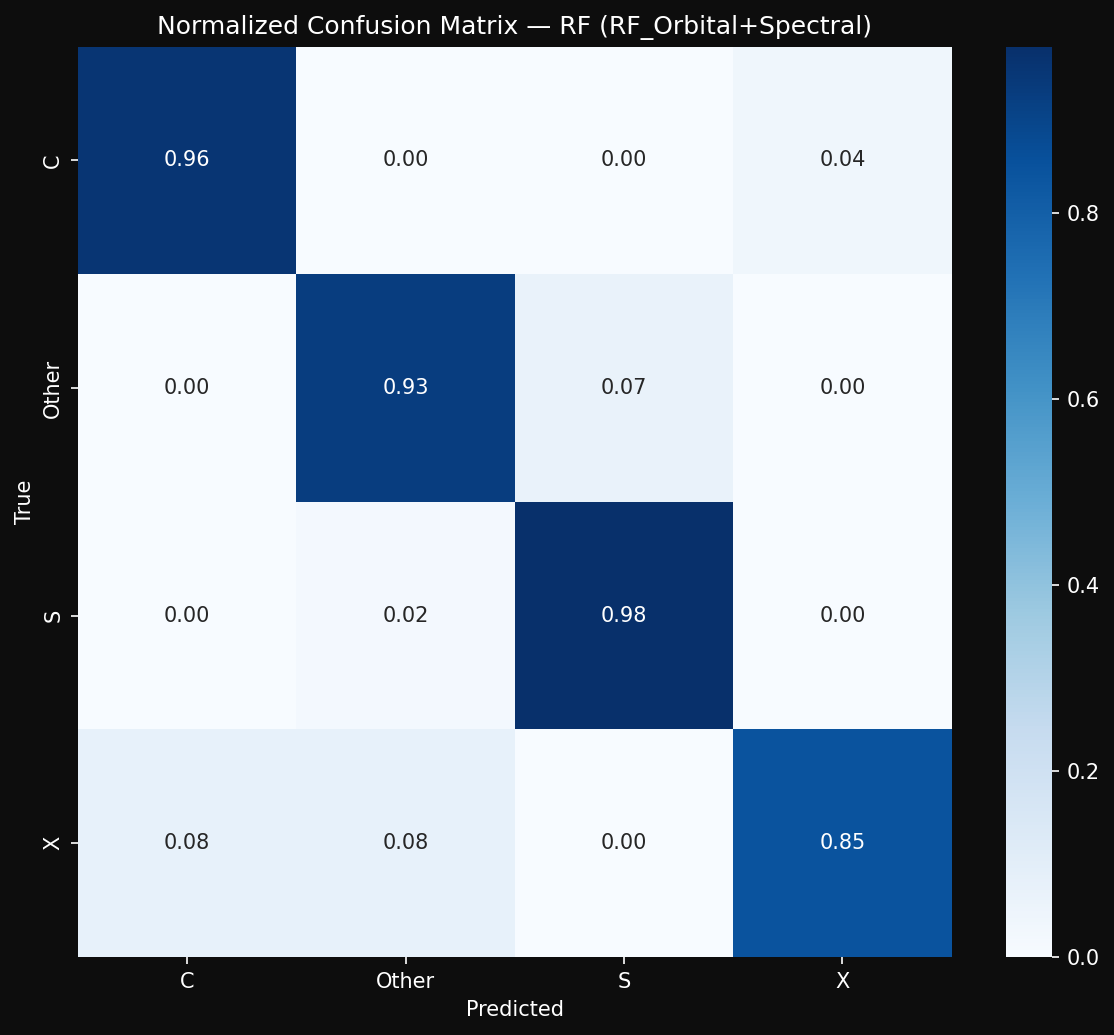


Classification Report:
              precision    recall  f1-score   support

           C      0.958     0.958     0.958        72
       Other      0.839     0.929     0.881        28
           S      0.980     0.980     0.980        98
           X      0.917     0.846     0.880        39

    accuracy                          0.945       237
   macro avg      0.923     0.928     0.925       237
weighted avg      0.946     0.945     0.945       237



In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)

# --------------------------------------------------
# Best RF model evaluation
# --------------------------------------------------

X_best = unified_df[best_features].astype(float).values

scaler = RobustScaler()
X_best_s = scaler.fit_transform(X_best)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_best_s,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

rf_cm = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_cm.fit(X_tr, y_tr)

y_pred = rf_cm.predict(X_te)

# --------------------------------------------------
# Metrics
# --------------------------------------------------

acc = accuracy_score(y_te, y_pred)
f1m = f1_score(y_te, y_pred, average='macro')
f1w = f1_score(y_te, y_pred, average='weighted')

print("\n" + "="*60)
print("BEST MODEL HOLDOUT PERFORMANCE")
print("="*60)
print(f"Accuracy    : {acc:.4f}")
print(f"F1 Macro    : {f1m:.4f}")
print(f"F1 Weighted : {f1w:.4f}")

# --------------------------------------------------
# Raw confusion matrix
# --------------------------------------------------

cm = confusion_matrix(y_te, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(
    f'Confusion Matrix — RF ({best_feat_name})'
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Normalized confusion matrix
# --------------------------------------------------

cm_norm = confusion_matrix(
    y_te,
    y_pred,
    normalize='true'
)

fig, ax = plt.subplots(figsize=(8, 7))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(
    f'Normalized Confusion Matrix — RF ({best_feat_name})'
)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Classification report
# --------------------------------------------------

print("\nClassification Report:")
print(
    classification_report(
        y_te,
        y_pred,
        target_names=le.classes_,
        digits=3
    )
)

In [15]:
cm_norm = confusion_matrix(
    y_te,
    y_pred,
    normalize='true'
)

cm_norm

array([[0.95833333, 0.        , 0.        , 0.04166667],
       [0.        , 0.92857143, 0.07142857, 0.        ],
       [0.        , 0.02040816, 0.97959184, 0.        ],
       [0.07692308, 0.07692308, 0.        , 0.84615385]])

In [16]:
with open(os.path.join(results_path, '05b_taxonomy_pred_orbi_spec_results.pkl'), 'wb') as f:
    pickle.dump({
        'cv_results'  : all_cv_results,
        'results_df'  : results_df,
        'le'          : le,
        'fam_f1'      : fam_f1,
        'bg_f1'       : bg_f1,
        'importances' : importances,
        'features'    : best_features,
    }, f)

print("Saved → data/results/05b_taxonomy_pred_orbi_spec_results.pkl")

Saved → data/results/05b_taxonomy_pred_orbi_spec_results.pkl
